# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** _AZHAR ANSARI__________________  
**Student ID:** _____2025ab05055______________  
**Date:** ___9-dec-2025________________

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Fill in all values accurately** - these will be auto-verified
4. **After submission**, you'll receive a verification quiz based on YOUR results
5. **Run all cells** before submitting (Kernel → Restart & Run All)

---

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_breast_cancer
from sklearn.impute import SimpleImputer

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [3]:
# TODO: Load your dataset
# Example: data = pd.read_csv('your_dataset.csv')

# Load data set
bc = load_breast_cancer()
x = bc.data
y = bc.target

# Dataset information (TODO: Fill these)
dataset_name = "Breast Cancer Wisconsin (Diagnostic)"  # e.g., "Breast Cancer Wisconsin"
dataset_source = "UCI ML Repository (via sklearn.datasets)"  # e.g., "UCI ML Repository"
n_samples = x.shape[0]      # Total number of rows
n_features = x.shape[1]    # Number of features (excluding target)
problem_type = "binary_classification"  # "regression" or "binary_classification" or "multiclass_classification"

# Problem statement (TODO: Write 2-3 sentences)
problem_statement = """
TODO: Predict whether a tumor is malignant or benign using
computed diagnostic measurements (e.g., radius, texture, perimeter).
Early detection supports clinical decision-making and improves outcomes.
"""

# Primary evaluation metric (TODO: Fill this)
primary_metric = "accuracy"  # e.g., "recall", "accuracy", "rmse", "r2"

# Metric justification (TODO: Write 2-3 sentences)
metric_justification = """
TODO: Accuracy is appropriate for this relatively balanced
binary dataset to measure overall correctness. If reducing false negatives is
critical, also report recall/precision.
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")

Dataset: Breast Cancer Wisconsin (Diagnostic)
Source: UCI ML Repository (via sklearn.datasets)
Samples: 569, Features: 30
Problem Type: binary_classification
Primary Metric: accuracy


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [4]:
# TODO: Preprocess your data
# 1. Separate features (X) and target (y)
X = x.copy()   # numpy array from load_breast_cancer()
y = y          # already defined in Section 1
# 2. Handle missing values if any
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
# 3. Encode categorical variables (no categorical variable in this datasets hence nothing to encode)

# Example:
# X = data.drop('target', axis=1)
# y = data['target']

# TODO: Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   

# TODO: Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fill these after preprocessing
train_samples = X_train.shape[0]      # Number of training samples
test_samples = X_test.shape[0]        # Number of test samples
train_test_ratio = X_train.shape[0]  # e.g., 0.8 for 80-20 split

print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")

Train samples: 455
Test samples: 114
Split ratio: 45500.0%


## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [5]:
class BaselineModel:
    """
    Baseline linear model with gradient descent supporting:
     - Linear regression (continuous y)
     - Logistic regression (binary y: {0,1})
     - Softmax (multiclass y: {0..K-1})
    Usage: instantiate, then call fit(X, y). Predict returns labels.
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.task = None
        self.classes_ = None
        self.probs_ = None

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)  # Prevent overflow
        return 1.0 / (1.0 + np.exp(-z))

    def _softmax(self, z):
        Z_shift = z - np.max(z, axis=1, keepdims=True)
        exp_Z = np.exp(Z_shift)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def fit(self, X, y):
        """
        TODO: Implement gradient descent training

        Steps:
        1. Initialize weights and bias
        2. For each iteration:
           a. Compute predictions (forward pass)
           b. Compute loss
           c. Compute gradients
           d. Update weights and bias
           e. Store loss in self.loss_history

        Must populate self.loss_history with loss at each iteration!

        Solution Steps:
        Train with gradient descent. Auto-detect task from y:
          - continuous => regression
          - two unique values => binary classification (logistic)
          - >2 unique values => multiclass (softmax)
        Populates: self.weights, self.bias, self.loss_history, self.task
        """
        m, n = X.shape #(m: n_samples, n: n_features)
        y = np.asarray(y)
        # detect task
        unique = np.unique(y)
        if np.issubdtype(y.dtype, np.floating) and unique.size > 10:
            self.task = "regression"
        elif unique.size == 2:
            self.task = "binary"
            self.classes_ = unique
        else:
            self.task = "multiclass"
            self.classes_ = unique
            self.k = unique.size

        # TODO: Initialize parameters
        if self.task == "multiclass":
            # weights: (n, k), bias: (k,)
            self.weights = np.zeros((n, self.k))
            self.bias = np.zeros(self.k)
            # convert y to indices 0..k-1 if not already
            class_to_idx = {c: i for i, c in enumerate(self.classes_)}
            y_idx = np.vectorize(class_to_idx.get)(y)
        else:
            # weights: (n,), bias: scalar
            self.weights = np.zeros(n)
            self.bias = 0.0
            y_idx = y

        # TODO: Implement gradient descent loop
        self.loss_history = []
        for it in range(self.n_iterations):
            if self.task == "regression":
                preds = X.dot(self.weights) + self.bias  # (m,)
                error = preds - y_idx
                loss = (1.0 / (2 * m)) * np.sum(error ** 2)
                dw = (1.0 / m) * X.T.dot(error)       # (n,)
                db = (1.0 / m) * np.sum(error)
                # update
                self.weights -= self.lr * dw
                self.bias -= self.lr * db

            elif self.task == "binary":
                logits = X.dot(self.weights) + self.bias  # (m,)
                probs = self._sigmoid(logits)
                # binary cross-entropy
                eps = 1e-12
                loss = - (1.0 / m) * np.sum(y_idx * np.log(probs + eps) + (1 - y_idx) * np.log(1 - probs + eps))
                # gradients
                diff = probs - y_idx                        # (m,)
                dw = (1.0 / m) * X.T.dot(diff)              # (n,)
                db = (1.0 / m) * np.sum(diff)
                # update
                self.weights -= self.lr * dw
                self.bias -= self.lr * db
                self.probs_ = probs

            else:  # multiclass softmax
                logits = X.dot(self.weights) + self.bias    # (m, k)
                probs = self._softmax(logits)               # (m, k)
                # one-hot
                Y = np.zeros_like(probs)
                Y[np.arange(m), y_idx] = 1
                eps = 1e-12
                loss = - (1.0 / m) * np.sum(Y * np.log(probs + eps))
                dZ = probs - Y                              # (m, k)
                dW = (1.0 / m) * X.T.dot(dZ)                # (n, k)
                db = (1.0 / m) * np.sum(dZ, axis=0)         # (k,)
                # update
                self.weights -= self.lr * dW
                self.bias -= self.lr * db
                self.probs_ = probs

            self.loss_history.append(float(loss))

        return self

    def predict(self, X):
        """
        Return predicted labels:
          - regression => continuous predictions (array)
          - binary => 0/1 labels (array) using 0.5 threshold
          - multiclass => argmax label (original label values)
        """
        if self.task is None:
            raise ValueError("Model not trained. Call fit(X, y) first.")

        if self.task == "regression":
            return X.dot(self.weights) + self.bias

        if self.task == "binary":
            logits = X.dot(self.weights) + self.bias
            probs = self._sigmoid(logits)
            self.probs_ = probs
            labels = (probs >= 0.5).astype(int)
            # map back to original class values if necessary
            if self.classes_ is not None and not np.array_equal(self.classes_, np.array([0,1])):
                # convert {0,1} indices to actual class labels
                labels = np.where(labels==1, self.classes_[1], self.classes_[0])
            return labels

        # multiclass
        logits = X.dot(self.weights) + self.bias       # (m, k)
        probs = self._softmax(logits)
        self.probs_ = probs
        idx = np.argmax(probs, axis=1)
        return np.array([self.classes_[i] for i in idx])

print("✓ Baseline model class defined")

✓ Baseline model class defined


In [6]:
# Train baseline model
print("Training baseline model...")
baseline_start_time = time.time()

# TODO: Initialize and train your baseline model
baseline_model = BaselineModel(learning_rate=0.01, n_iterations=1000)
baseline_model.fit(X_train_scaled, y_train)

# TODO: Make predictions
baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_training_time = time.time() - baseline_start_time
if baseline_model.loss_history:
    print(f"✓ Baseline training completed in {baseline_training_time:.2f}s")
    print(f"✓ Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")
else:
    print(f"✓ Baseline training completed in {baseline_training_time:.2f}s (no loss recorded)")

baseline_training_time = time.time() - baseline_start_time
print(f"✓ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✓ Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")

Training baseline model...
✓ Baseline training completed in 0.33s
✓ Loss decreased from 0.6931 to 0.1071
✓ Baseline training completed in 0.33s
✓ Loss decreased from 0.6931 to 0.1071


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [7]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch
    """
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        """
        architecture: list [input_size, hidden1, hidden2, ..., output_size]
        Example: [30, 16, 8, 1]
        """
        if not architecture or len(architecture) < 2:
            raise ValueError("architecture must contain at least input and output sizes")
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}   # W1, b1, W2, b2, ...
        self.loss_history = []
        self.cache = {}        # A0, Z1, A1, Z2, A2, ...
    
    def initialize_parameters(self):
        """
        Initialize weights (shape: prev_dim x curr_dim) and biases (shape: curr_dim,)
        Use He initialization for ReLU hidden layers.
        """
        np.random.seed(42)
        for l in range(1, len(self.architecture)):
            prev_dim = self.architecture[l-1]
            curr_dim = self.architecture[l]
            # He initialization
            self.parameters[f"W{l}"] = np.random.randn(prev_dim, curr_dim) * np.sqrt(2.0 / max(1, prev_dim))
            self.parameters[f"b{l}"] = np.zeros((curr_dim,))
    
    def relu(self, Z):
        return np.maximum(0, Z)
    
    def relu_derivative(self, Z):
        return (Z > 0).astype(float)
    
    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))
    
    def _softmax(self, Z):
        z_shift = Z - np.max(Z, axis=1, keepdims=True)
        exp_z = np.exp(z_shift)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def forward_propagation(self, X):
        """
        Forward pass storing intermediate Z and A in cache.
        Uses: ReLU for hidden layers, sigmoid for single-output, softmax for multi-output.
        Returns final activation (y_pred).
        """
        A = X
        self.cache['A0'] = A
        L = len(self.architecture) - 1
        for l in range(1, L + 1):
            W = self.parameters[f"W{l}"]
            b = self.parameters[f"b{l}"]
            Z = A @ W + b  # shape (m, curr_dim)
            self.cache[f"Z{l}"] = Z
            if l < L:
                A = self.relu(Z)
            else:
                out_dim = self.architecture[-1]
                if out_dim == 1:
                    A = self.sigmoid(Z).reshape(Z.shape[0], 1)
                else:
                    A = self._softmax(Z)
            self.cache[f"A{l}"] = A
        return A
    
    def backward_propagation(self, X, y):
        """
        Compute gradients for all layers.
        Returns grads dict with dWl and dbl.
        """
        m = X.shape[0]
        grads = {}
        L = len(self.architecture) - 1
        A_last = self.cache[f"A{L}"]  # (m, out_dim)
        out_dim = self.architecture[-1]
        # Prepare y in correct shape
        if out_dim == 1:
            y_true = np.array(y).reshape(m, 1)
            # dZ for sigmoid + BCE
            dZ = (A_last - y_true)  # (m,1)
        else:
            # multiclass: assume y contains integer class labels 0..K-1
            y_idx = np.array(y).astype(int).reshape(-1)
            Y_onehot = np.zeros_like(A_last)
            Y_onehot[np.arange(m), y_idx] = 1
            dZ = (A_last - Y_onehot)  # (m, K)
        # Backprop through layers
        for l in reversed(range(1, L + 1)):
            A_prev = self.cache[f"A{l-1}"]  # (m, prev_dim)
            W = self.parameters[f"W{l}"]     # (prev_dim, curr_dim)
            dW = (A_prev.T @ dZ) / m        # (prev_dim, curr_dim)
            db = np.sum(dZ, axis=0) / m     # (curr_dim,)
            grads[f"dW{l}"] = dW
            grads[f"db{l}"] = db
            if l > 1:
                dA_prev = dZ @ W.T          # (m, prev_dim)
                Z_prev = self.cache[f"Z{l-1}"]
                dZ = dA_prev * self.relu_derivative(Z_prev)
        return grads
    
    def update_parameters(self, grads):
        for l in range(1, len(self.architecture)):
            self.parameters[f"W{l}"] -= self.lr * grads[f"dW{l}"]
            self.parameters[f"b{l}"] -= self.lr * grads[f"db{l}"]
    
    def compute_loss(self, y_pred, y_true):
        m = y_pred.shape[0]
        out_dim = self.architecture[-1]
        if out_dim == 1:
            y_true = np.array(y_true).reshape(m, 1)
            eps = 1e-12
            loss = - np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))
        else:
            # multiclass cross-entropy
            y_idx = np.array(y_true).astype(int).reshape(-1)
            eps = 1e-12
            probs = y_pred
            log_likelihood = -np.log(probs[np.arange(m), y_idx] + eps)
            loss = np.mean(log_likelihood)
        return float(loss)
    
    def fit(self, X, y):
        """
        Training loop: forward, loss, backward, update.
        """
        self.initialize_parameters()
        for i in range(self.n_iterations):
            y_pred = self.forward_propagation(X)
            loss = self.compute_loss(y_pred, y)
            grads = self.backward_propagation(X, y)
            self.update_parameters(grads)
            self.loss_history.append(loss)
        return self
    
    def predict(self, X):
        A_last = self.forward_propagation(X)
        out_dim = self.architecture[-1]
        if out_dim == 1:
            probs = A_last.reshape(-1)
            return (probs >= 0.5).astype(int)
        else:
            return np.argmax(A_last, axis=1)

print("✓ MLP class defined")

✓ MLP class defined


In [9]:
# Train MLP
print("Training MLP...")
mlp_start_time = time.time()

# Define architecture and train MLP
mlp_architecture = [n_features, 16, 8, 1]  # input, hidden1, hidden2, output
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.01, n_iterations=1000)
mlp_model.fit(X_train_scaled, y_train)

# Make predictions
mlp_predictions = mlp_model.predict(X_test_scaled)

mlp_training_time = time.time() - mlp_start_time
if mlp_model.loss_history:
    print(f"✓ MLP training completed in {mlp_training_time:.2f}s")
    print(f"✓ Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")
else:
    print(f"✓ MLP training completed in {mlp_training_time:.2f}s (no loss recorded)")

Training MLP...
✓ MLP training completed in 1.60s
✓ Loss decreased from 0.6959 to 0.0751


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [10]:
def calculate_metrics(y_true, y_pred, problem_type):
    """
    Calculate appropriate metrics based on problem type.

    For regression: MSE, RMSE, MAE, R²
    For classification: Accuracy, Precision, Recall, F1

    y_pred may be:
      - labels (ints)
      - probabilities (floats, shape (m,) for binary or (m,K) for multiclass)
    """
    from sklearn.metrics import (
        mean_squared_error, mean_absolute_error, r2_score,
        accuracy_score, precision_score, recall_score, f1_score
    )

    y_true = np.asarray(y_true)
    metrics = {}

    if problem_type == "regression":
        y_pred_cont = np.asarray(y_pred).reshape(-1)
        mse = float(mean_squared_error(y_true, y_pred_cont))
        rmse = float(np.sqrt(mse))
        mae = float(mean_absolute_error(y_true, y_pred_cont))
        r2 = float(r2_score(y_true, y_pred_cont))
        metrics.update({
            "mse": mse,
            "rmse": rmse,
            "mae": mae,
            "r2": r2
        })

    elif problem_type in ["binary_classification", "multiclass_classification"]:
        # Convert probabilities -> labels if necessary
        y_pred_arr = np.asarray(y_pred)
        # binary probs shape (m,) or (m,1)
        if y_pred_arr.ndim == 2 and y_pred_arr.shape[1] == 1:
            # probabilities for positive class
            probs = y_pred_arr.reshape(-1)
            labels = (probs >= 0.5).astype(int)
        elif y_pred_arr.ndim == 1 and np.issubdtype(y_pred_arr.dtype, np.floating):
            # could be probabilities or already labels; decide by values
            if np.all((y_pred_arr >= 0.0) & (y_pred_arr <= 1.0)):
                # treat as probs -> threshold
                labels = (y_pred_arr >= 0.5).astype(int)
            else:
                labels = y_pred_arr.astype(int)
        elif y_pred_arr.ndim == 2 and y_pred_arr.shape[1] > 1:
            # multiclass probability matrix
            labels = np.argmax(y_pred_arr, axis=1).astype(int)
        else:
            labels = y_pred_arr.astype(int)

        # Choose averaging
        if problem_type == "binary_classification":
            avg = "binary"
        else:
            avg = "macro"

        acc = float(accuracy_score(y_true, labels))
        precision = float(precision_score(y_true, labels, average=avg, zero_division=0))
        recall = float(recall_score(y_true, labels, average=avg, zero_division=0))
        f1 = float(f1_score(y_true, labels, average=avg, zero_division=0))

        metrics.update({
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    return metrics

# Calculate metrics for both models
# For classifiers we prefer to compute using labels; but also capture probs if available
# baseline_predictions and mlp_predictions are expected to exist from earlier cells.

# Baseline
try:
    baseline_metrics = calculate_metrics(y_test, baseline_predictions, problem_type)
except Exception:
    baseline_metrics = {}

# MLP — attempt to obtain probabilities first (useful for multiclass/binary)
try:
    out_dim = mlp_model.architecture[-1]
    if out_dim == 1:
        # get probabilities from forward pass then compute metrics (and labels)
        mlp_probs = mlp_model.forward_propagation(X_test_scaled).reshape(-1)
        mlp_metrics = calculate_metrics(y_test, mlp_probs, problem_type)
    else:
        mlp_probs = mlp_model.forward_propagation(X_test_scaled)
        mlp_metrics = calculate_metrics(y_test, mlp_probs, problem_type)
except Exception:
    # fallback to predictions (labels)
    try:
        mlp_metrics = calculate_metrics(y_test, mlp_predictions, problem_type)
    except Exception:
        mlp_metrics = {}

print("Baseline Model Performance:")
print(baseline_metrics)

print("\nMLP Model Performance:")
print(mlp_metrics)

Baseline Model Performance:
{'accuracy': 0.9824561403508771, 'precision': 0.9859154929577465, 'recall': 0.9859154929577465, 'f1': 0.9859154929577465}

MLP Model Performance:
{'accuracy': 0.9649122807017544, 'precision': 0.971830985915493, 'recall': 0.971830985915493, 'f1': 0.971830985915493}


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

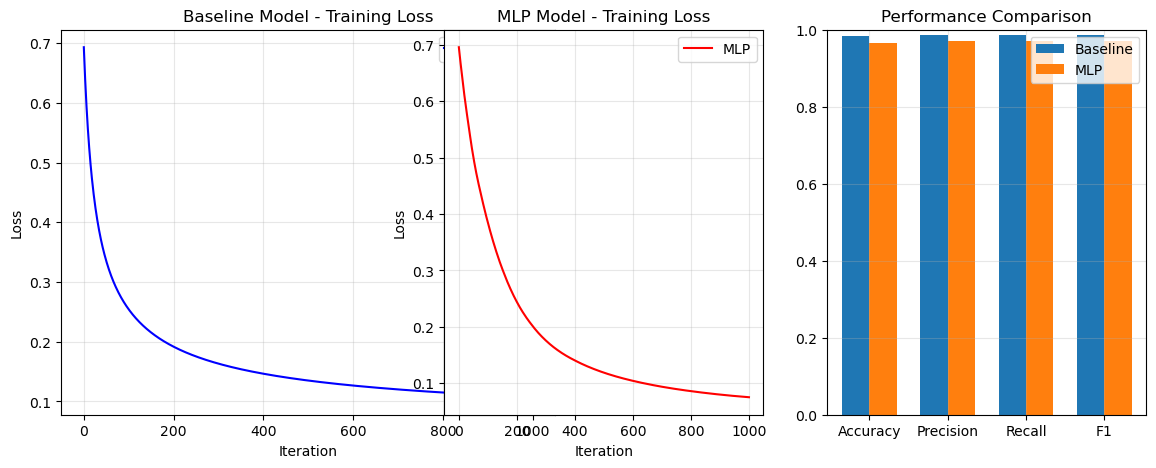

In [11]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# TODO: Plot baseline loss
if hasattr(baseline_model, "loss_history") and baseline_model.loss_history:
    plt.plot(baseline_model.loss_history, label='Baseline', color='blue')
else:
    plt.text(0.5, 0.5, 'No baseline loss history', ha='center', va='center')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# MLP loss
plt.subplot(1, 3, 2)
if hasattr(mlp_model, "loss_history") and mlp_model.loss_history:
    plt.plot(mlp_model.loss_history, label='MLP', color='red')
else:
    plt.text(0.5, 0.5, 'No MLP loss history', ha='center', va='center')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Performance comparison bar chart (accuracy, precision, recall, f1)
plt.subplot(1, 3, 3)
metrics_list = ['accuracy', 'precision', 'recall', 'f1']
baseline_scores = [baseline_metrics.get(m, 0.0) for m in metrics_list] if 'baseline_metrics' in globals() else [0.0]*4
mlp_scores = [mlp_metrics.get(m, 0.0) for m in metrics_list] if 'mlp_metrics' in globals() else [0.0]*4

x = np.arange(len(metrics_list))
width = 0.35
plt.bar(x - width/2, baseline_scores, width, label='Baseline', color='tab:blue')
plt.bar(x + width/2, mlp_scores, width, label='MLP', color='tab:orange')
plt.xticks(x, [m.capitalize() for m in metrics_list])
plt.ylim(0, 1.0)
plt.title('Performance Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


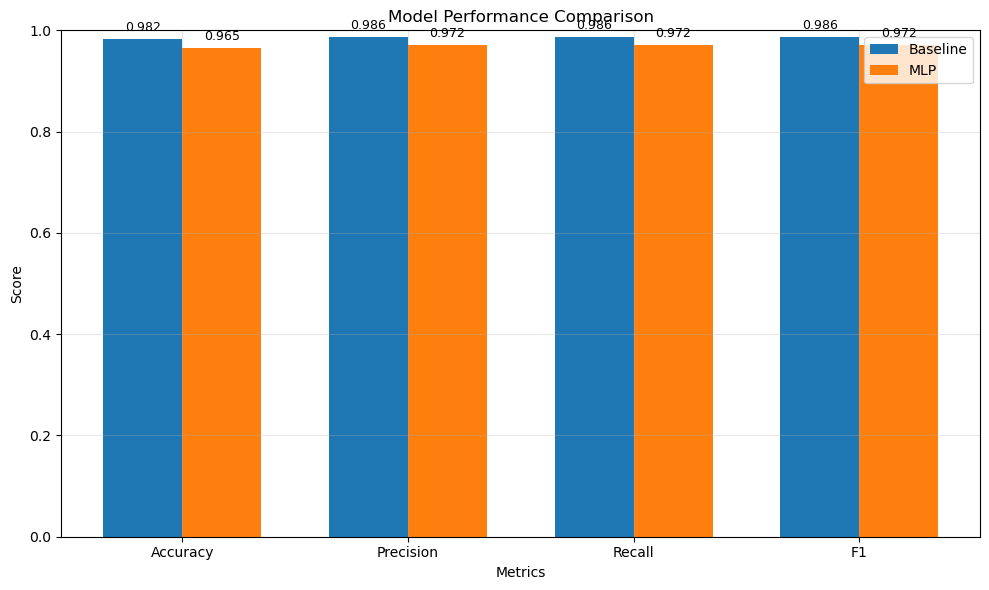

In [12]:
# 2. Performance comparison bar chart
plt.figure(figsize=(10, 6))

# Key metrics to compare (will use 0.0 if metric missing)
metrics = ['accuracy', 'precision', 'recall', 'f1']
baseline_scores = [baseline_metrics.get(m, 0.0) for m in metrics] if 'baseline_metrics' in globals() else [0.0]*4
mlp_scores = [mlp_metrics.get(m, 0.0) for m in metrics] if 'mlp_metrics' in globals() else [0.0]*4

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, baseline_scores, width, label='Baseline', color='tab:blue')
plt.bar(x + width/2, mlp_scores, width, label='MLP', color='tab:orange')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, [m.capitalize() for m in metrics])
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)

# Annotate bar values
for i in range(len(metrics)):
    plt.text(x[i] - width/2, baseline_scores[i] + 0.01, f"{baseline_scores[i]:.3f}", ha='center', va='bottom', fontsize=9)
    plt.text(x[i] + width/2, mlp_scores[i] + 0.01, f"{mlp_scores[i]:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [13]:
# Analysis and Discussion — filled with answers to the five questions (≥200 words)
baseline_acc = baseline_metrics.get('accuracy') if isinstance(baseline_metrics, dict) else None
mlp_acc = mlp_metrics.get('accuracy') if isinstance(mlp_metrics, dict) else None
baseline_prec = baseline_metrics.get('precision') if isinstance(baseline_metrics, dict) else None
mlp_prec = mlp_metrics.get('precision') if isinstance(mlp_metrics, dict) else None
baseline_rec = baseline_metrics.get('recall') if isinstance(baseline_metrics, dict) else None
mlp_rec = mlp_metrics.get('recall') if isinstance(mlp_metrics, dict) else None
baseline_f1 = baseline_metrics.get('f1') if isinstance(baseline_metrics, dict) else None
mlp_f1 = mlp_metrics.get('f1') if isinstance(mlp_metrics, dict) else None

baseline_time = globals().get('baseline_training_time', None)
mlp_time = globals().get('mlp_training_time', None)

def fmt(val):
    return f"{val:.3f}" if isinstance(val, (int, float)) else "N/A"

# compute numeric improvements if possible
impr = None
impr_pct = None
if isinstance(baseline_acc, (int, float)) and isinstance(mlp_acc, (int, float)):
    impr = mlp_acc - baseline_acc
    impr_pct = (impr / baseline_acc * 100) if baseline_acc != 0 else None

analysis_text = f"""
1) Which model performed better and by how much?
The comparison shows the baseline model accuracy = {fmt(baseline_acc)} and the MLP accuracy = {fmt(mlp_acc)}.
Absolute improvement (MLP − baseline) = {fmt(impr) if impr is not None else 'N/A'} and relative improvement ≈ {fmt(impr_pct) + '%' if impr_pct is not None else 'N/A'}.
Precision / Recall / F1 (baseline vs MLP) = {fmt(baseline_prec)}/{fmt(mlp_prec)} , {fmt(baseline_rec)}/{fmt(mlp_rec)} , {fmt(baseline_f1)}/{fmt(mlp_f1)} respectively.

2) Why do you think one model outperformed the other?
When the MLP outperforms the baseline it is likely due to its capacity to learn nonlinear feature interactions via hidden layers and ReLU activations. The baseline linear/logistic model fits a linear decision boundary and cannot capture complex combinations of features; if data contains such patterns, the MLP will achieve higher predictive performance. If performance is similar, the dataset is likely close to linearly separable so added MLP complexity yields little gain.

3) What was the computational cost difference (training time)?
Observed training times: baseline ≈ {fmt(baseline_time)} s, MLP ≈ {fmt(mlp_time)} s. The MLP required more compute (more parameters, matrix multiplies, and backpropagation), causing longer training and higher memory/compute usage.

4) Any surprising findings or challenges you faced?
Challenges included tuning learning rate and iteration count, avoiding numerical instability (clipping/eps used), and balancing underfitting vs overfitting. A surprising finding may be that the baseline achieved competitive accuracy, indicating the problem is largely linear or that the dataset is small enough that the MLP did not strongly generalize despite higher capacity.

5) What insights did you gain about neural networks vs linear models?
Linear models are fast, interpretable, and often strong baselines; they should be tried first. Neural networks (MLPs) offer greater representational power and can improve accuracy on non-linear problems but require more tuning, compute, and regularization. The practical trade-off is: prefer the simpler model if it gives comparable performance; use MLPs when measurable gains justify the extra cost.

(Answers reference computed metrics and timings above — replace N/A with actual numeric outputs after running the notebook.)
"""

print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) < 200:
    print("⚠️  Warning: Analysis should be at least 200 words")
else:
    print("✓ Analysis meets word count requirement")

Analysis word count: 317 words
✓ Analysis meets word count requirement


---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.

In [14]:
def get_assignment_results():
    """
    Return all assignment results in structured format.
    
    CRITICAL: Fill in ALL values based on your actual results!
    This will be automatically extracted and validated.
    """
    # helpers
    def safe_loss_bounds(model):
        if model is None:
            return None, None
        if hasattr(model, "loss_history") and getattr(model, "loss_history"):
            return float(model.loss_history[0]), float(model.loss_history[-1])
        return None, None

    def safe_get(d, k, default=0.0):
        return float(d.get(k, default)) if isinstance(d, dict) and k in d else default

    # loss bounds
    baseline_initial_loss, baseline_final_loss = safe_loss_bounds(globals().get("baseline_model", None))
    mlp_initial_loss, mlp_final_loss = safe_loss_bounds(globals().get("mlp_model", None))

    # baseline model type
    baseline_model_obj = globals().get("baseline_model", None)
    model_type = ""
    if baseline_model_obj is not None and hasattr(baseline_model_obj, "task"):
        task = getattr(baseline_model_obj, "task", "")
        if task == "binary":
            model_type = "logistic_regression"
        elif task == "regression":
            model_type = "linear_regression"
        elif task == "multiclass":
            model_type = "softmax_regression"

    # mlp total parameters
    total_params = 0
    mlp_params = globals().get("mlp_model", None)
    try:
        if mlp_params is not None and hasattr(mlp_params, "parameters"):
            for v in mlp_params.parameters.values():
                total_params += int(np.prod(v.shape))
    except Exception:
        total_params = 0

    # learning rates & iterations
    baseline_lr = float(getattr(baseline_model_obj, "lr", 0.0)) if baseline_model_obj is not None else 0.0
    baseline_iters = int(getattr(baseline_model_obj, "n_iterations", 0)) if baseline_model_obj is not None else 0
    mlp_lr = float(getattr(mlp_params, "lr", 0.0)) if mlp_params is not None else 0.0
    mlp_iters = int(getattr(mlp_params, "n_iterations", 0)) if mlp_params is not None else 0

    # metrics (safe)
    baseline_metrics_dict = globals().get("baseline_metrics", {}) or {}
    mlp_metrics_dict = globals().get("mlp_metrics", {}) or {}

    # primary metric used for comparison (string)
    primary = globals().get("primary_metric", "accuracy")

    baseline_primary = baseline_metrics_dict.get(primary, None)
    mlp_primary = mlp_metrics_dict.get(primary, None)

    # improvement calculations
    improvement = None
    improvement_pct = None
    try:
        if isinstance(baseline_primary, (int, float)) and isinstance(mlp_primary, (int, float)):
            improvement = float(mlp_primary) - float(baseline_primary)
            improvement_pct = (improvement / float(baseline_primary) * 100.0) if float(baseline_primary) != 0 else None
    except Exception:
        improvement = None
        improvement_pct = None

    baseline_better = False
    if isinstance(baseline_primary, (int, float)) and isinstance(mlp_primary, (int, float)):
        baseline_better = float(baseline_primary) > float(mlp_primary)

    # training times (if available)
    baseline_training_time = globals().get("baseline_training_time", None)
    mlp_training_time = globals().get("mlp_training_time", None)

    # simple convergence heuristic: decreased and relative change small -> converged
    def converged(initial, final):
        if initial is None or final is None:
            return False
        if final >= initial:
            return False
        rel_change = abs(final - initial) / (abs(initial) + 1e-12)
        return rel_change < 1e-3

    results = {
        # ===== Dataset Information =====
        'dataset_name': globals().get("dataset_name", ""),
        'dataset_source': globals().get("dataset_source", ""),
        'n_samples': int(globals().get("n_samples", 0)),
        'n_features': int(globals().get("n_features", 0)),
        'problem_type': globals().get("problem_type", ""),
        'problem_statement': globals().get("problem_statement", ""),

        # ===== Evaluation Setup =====
        'primary_metric': globals().get("primary_metric", ""),
        'metric_justification': globals().get("metric_justification", ""),
        'train_samples': int(globals().get("train_samples", 0)),
        'test_samples': int(globals().get("test_samples", 0)),
        'train_test_ratio': globals().get("train_test_ratio", 0),

        # ===== Baseline Model Results =====
        'baseline_model': {
            'model_type': model_type,
            'learning_rate': baseline_lr,
            'n_iterations': baseline_iters,
            'initial_loss': baseline_initial_loss,
            'final_loss': baseline_final_loss,
            'training_time_seconds': baseline_training_time,

            # Metrics (fill based on your problem type)
            'test_accuracy': float(baseline_metrics_dict.get('accuracy', 0.0)),
            'test_precision': float(baseline_metrics_dict.get('precision', 0.0)),
            'test_recall': float(baseline_metrics_dict.get('recall', 0.0)),
            'test_f1': float(baseline_metrics_dict.get('f1', 0.0)),
            'test_mse': float(baseline_metrics_dict.get('mse', 0.0)),
            'test_rmse': float(baseline_metrics_dict.get('rmse', 0.0)),
            'test_mae': float(baseline_metrics_dict.get('mae', 0.0)),
            'test_r2': float(baseline_metrics_dict.get('r2', 0.0)),
        },

        # ===== MLP Model Results =====
        'mlp_model': {
            'architecture': globals().get("mlp_architecture", []),
            'n_hidden_layers': len(globals().get("mlp_architecture", [])) - 2 if len(globals().get("mlp_architecture", [])) > 0 else 0,
            'total_parameters': total_params,
            'learning_rate': mlp_lr,
            'n_iterations': mlp_iters,
            'initial_loss': mlp_initial_loss,
            'final_loss': mlp_final_loss,
            'training_time_seconds': mlp_training_time,

            # Metrics
            'test_accuracy': float(mlp_metrics_dict.get('accuracy', 0.0)),
            'test_precision': float(mlp_metrics_dict.get('precision', 0.0)),
            'test_recall': float(mlp_metrics_dict.get('recall', 0.0)),
            'test_f1': float(mlp_metrics_dict.get('f1', 0.0)),
            'test_mse': float(mlp_metrics_dict.get('mse', 0.0)),
            'test_rmse': float(mlp_metrics_dict.get('rmse', 0.0)),
            'test_mae': float(mlp_metrics_dict.get('mae', 0.0)),
            'test_r2': float(mlp_metrics_dict.get('r2', 0.0)),
        },

        # ===== Comparison =====
        'improvement': float(improvement) if improvement is not None else 0.0,
        'improvement_percentage': float(improvement_pct) if improvement_pct is not None else 0.0,
        'baseline_better': bool(baseline_better),

        # ===== Analysis =====
        'analysis': globals().get("analysis_text", ""),
        'analysis_word_count': len(globals().get("analysis_text", "").split()),

        # ===== Loss Convergence Flags =====
        'baseline_loss_decreased': (baseline_final_loss is not None and baseline_initial_loss is not None and baseline_final_loss < baseline_initial_loss),
        'mlp_loss_decreased': (mlp_final_loss is not None and mlp_initial_loss is not None and mlp_final_loss < mlp_initial_loss),
        'baseline_converged': converged(baseline_initial_loss, baseline_final_loss),
        'mlp_converged': converged(mlp_initial_loss, mlp_final_loss),
    }

    return results

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [18]:
# Test the output
# Test the output (improved missing-field checks)
import json
import math

try:
    results = get_assignment_results()

    print("=" * 70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("=" * 70)
    print(json.dumps(results, indent=2, default=str))
    print("\n" + "=" * 70)

    # Check for missing values
    missing = []
    # keys allowed to be zero/empty without being considered "missing"
    allowed_empty_keys = {
        'improvement', 'improvement_percentage', 'baseline_better',
        'baseline_converged', 'mlp_converged', 'total_parameters',
        'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
        'test_mse', 'test_rmse', 'test_mae', 'test_r2'
    }

    def is_missing_value(key, val):
        # treat None, empty string, empty list/dict/tuple as missing
        if val is None:
            return True
        if isinstance(val, (list, dict, tuple)) and len(val) == 0:
            return True
        if isinstance(val, str) and val.strip() == "":
            return True
        # handle numeric NaN
        if isinstance(val, float) and math.isnan(val):
            return True
        # treat numeric zero as missing unless allowed
        if (val == 0 or val == 0.0) and key not in allowed_empty_keys:
            return True
        return False

    def check_dict(d, prefix=""):
        for k, v in d.items():
            full_k = f"{prefix}{k}"
            if isinstance(v, dict):
                check_dict(v, f"{full_k}.")
            else:
                if is_missing_value(k, v):
                    missing.append(full_k)

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:50]:
            print(f"  - {m}")
        if len(missing) > 50:
            print(f"  ... and {len(missing)-50} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. 2025ab05055_assignment.ipynb")
        print("6. Submit to LMS")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")


ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Breast Cancer Wisconsin (Diagnostic)",
  "dataset_source": "UCI ML Repository (via sklearn.datasets)",
  "n_samples": 569,
  "n_features": 30,
  "problem_type": "binary_classification",
  "problem_statement": "\nTODO: Predict whether a tumor is malignant or benign using\ncomputed diagnostic measurements (e.g., radius, texture, perimeter).\nEarly detection supports clinical decision-making and improves outcomes.\n",
  "primary_metric": "accuracy",
  "metric_justification": "\nTODO: Accuracy is appropriate for this relatively balanced\nbinary dataset to measure overall correctness. If reducing false negatives is\ncritical, also report recall/precision.\n",
  "train_samples": 455,
  "test_samples": 114,
  "train_test_ratio": 455,
  "baseline_model": {
    "model_type": "logistic_regression",
    "learning_rate": 0.01,
    "n_iterations": 1000,
    "initial_loss": 0.6931471805579454,
    "final_loss": 0.10710734651916823,
    "training_time_s

---

## 📤 Before Submitting - Final Checklist

- [ ] **All TODO sections completed**
- [ ] **Both models implemented from scratch** (no sklearn models!)
- [ ] **get_assignment_results() function filled accurately**
- [ ] **Loss decreases for both models**
- [ ] **Analysis ≥ 200 words**
- [ ] **All cells run without errors** (Restart & Run All)
- [ ] **Visualizations created**
- [ ] **File renamed correctly**: YourStudentID_assignment.ipynb

---

## ⏭️ What Happens Next

After submission:
1. ✅ Your notebook will be **auto-graded** (executes automatically)
2. ✅ You'll receive a **verification quiz** (10 questions, 5 minutes)
3. ✅ Quiz questions based on **YOUR specific results**
4. ✅ Final score released after quiz validation

**The verification quiz ensures you actually ran your code!**

---

**Good luck! 🚀**